In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

sns.set(style="ticks")
#sns.set(style="whitegrid", color_codes=True)

data1 = pd.read_excel('CFST Database.xlsx', sheet_name='Sheet1')
data1.head()

,Authors,specimen,D(mm),t(mm),P,P0 (kN),Ast (mm2),Ac (mm2),a/D,P/P0,fc (MPa),fy (MPa),Vtest (kN)
0,Qian et al. (2007),A1-11,194.0,5.5,0.0,2086.227485,3255.40,26301.42,0.1,0.000,40.5,330.0,1002.0
1,Qian et al. (2007),B1-11,194.0,7.5,0.0,2821.648245,4392.08,25164.20,0.1,0.000,40.5,422.0,1204.0
2,Qian et al. (2007),A1-21,194.0,5.5,900.0,2086.227485,3255.40,26301.42,0.1,0.431,40.5,330.0,1295.0
3,Qian et al. (2007),B1-21,194.0,7.5,1307.0,2821.648245,4392.08,25164.20,0.1,0.463,40.5,422.0,1618.0
4,Qian et al. (2007),A1-31,194.0,5.5,1500.0,2086.227485,3255.40,26301.42,0.1,0.719,40.5,330.0,1604.0


In [2]:
data=data1.loc[:, 'Ast (mm2)':'Vtest (kN)']
data.head()

,Ast (mm2),Ac (mm2),a/D,P/P0,fc (MPa),fy (MPa),Vtest (kN)
0,3255.40,26301.42,0.1,0.000,40.5,330.0,1002.0
1,4392.08,25164.20,0.1,0.000,40.5,422.0,1204.0
2,3255.40,26301.42,0.1,0.431,40.5,330.0,1295.0
3,4392.08,25164.20,0.1,0.463,40.5,422.0,1618.0
4,3255.40,26301.42,0.1,0.719,40.5,330.0,1604.0


In [3]:
print(data.shape)

(230, 7)


In [4]:
data.describe()

,Ast (mm2),Ac (mm2),a/D,P/P0,fc (MPa),fy (MPa),Vtest (kN)
count,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000,230.000000
mean,2433.859565,29263.512565,0.259152,0.255152,39.312670,373.090870,870.841522
std,1486.740543,29151.265799,0.136223,0.222867,12.116456,66.633621,602.415544
min,741.040000,9116.560000,0.075000,0.000000,19.200000,276.800000,240.000000
25%,1526.040000,17436.110000,0.140000,0.000000,29.500000,330.000000,435.625000
50%,2191.790000,19855.070000,0.250000,0.253000,35.990000,346.950000,627.500000
75%,3184.910000,25164.200000,0.386250,0.452750,46.000000,408.000000,1210.500000
max,10002.400000,192669.840000,0.500000,0.850000,67.500000,549.000000,3569.000000


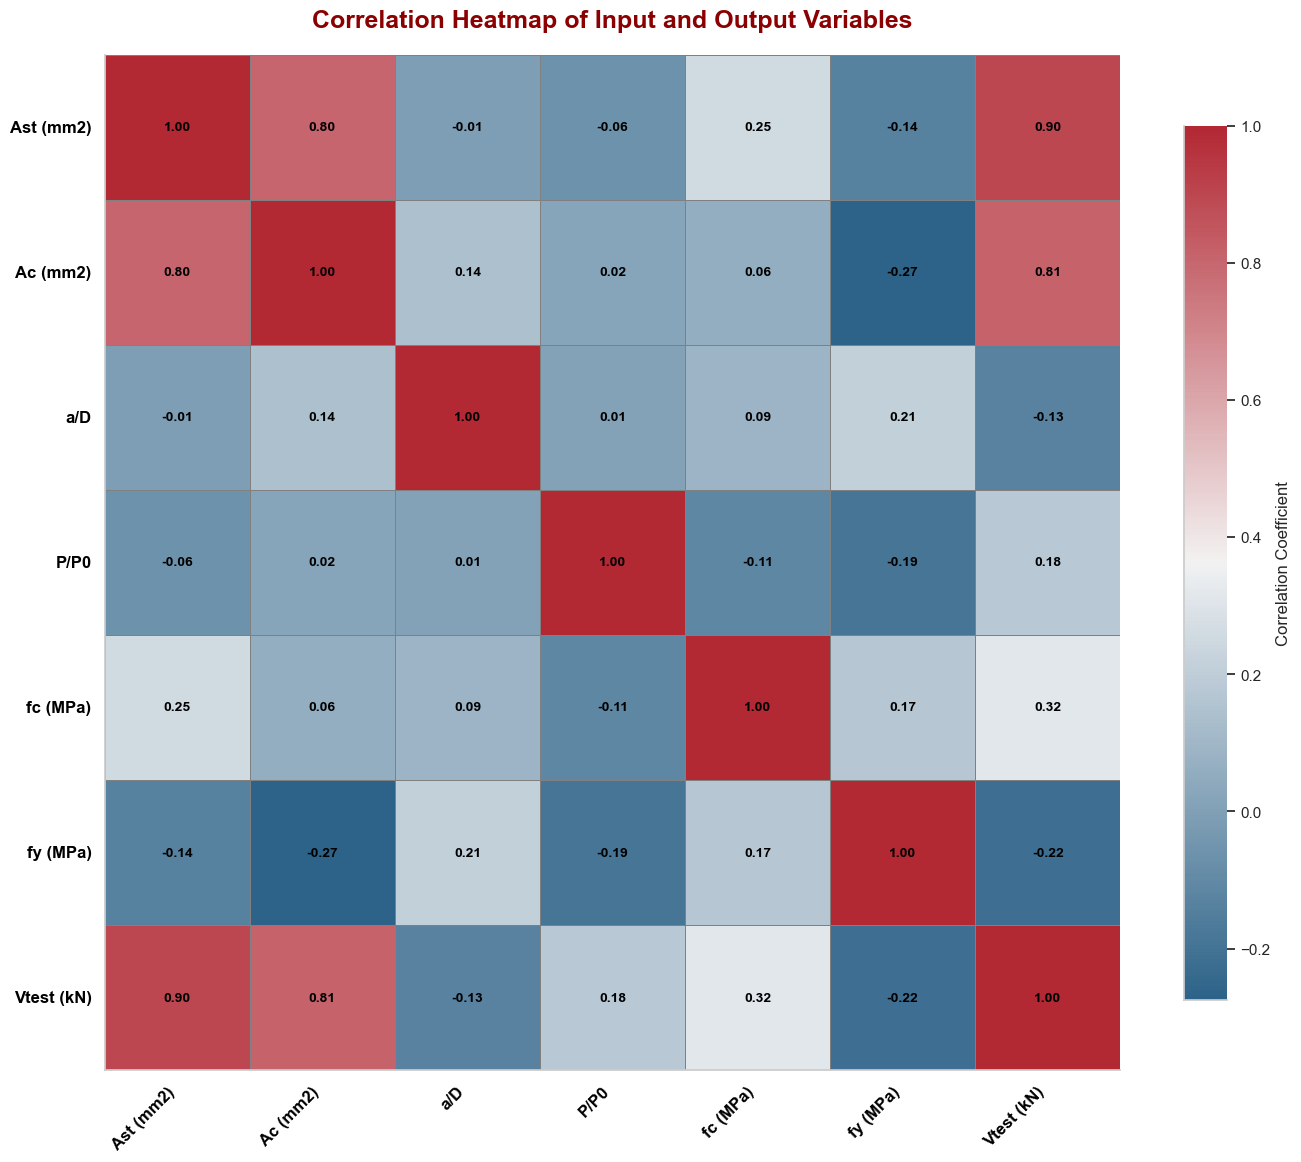

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix
corr_matrix = data.corr()

# Set up the figure
plt.figure(figsize=(14, 12))
sns.set_theme(style="whitegrid")

# Define a balanced and visually clean colormap suitable for publications
cmap = sns.diverging_palette(240, 10, s=80, l=40, as_cmap=True)

# Create the heatmap
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=cmap,
    fmt=".2f",
    linewidths=0.6,
    linecolor='gray',
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation Coefficient",
        "orientation": "vertical"
    },
    square=True,
    annot_kws={"size": 10, "weight": "bold", "color": "black"}
)

# Axis label styling
plt.xticks(
    rotation=45,
    ha="right",
    fontsize=12,
    fontweight="bold",
    color="black"
)
plt.yticks(
    rotation=0,
    fontsize=12,
    fontweight="bold",
    color="black"
)

# Title styling
plt.title(
    "Correlation Heatmap of Input and Output Variables",
    fontsize=18,
    fontweight="bold",
    color="darkred",
    pad=20
)

# Remove top and right spines for a cleaner look
sns.despine(left=False, bottom=False)

# Adjust layout for tight fit
plt.tight_layout()

# Save the figure (High-resolution, suitable for journal submission)
plt.savefig(
    "correlation_heatmap_highres.png",
    dpi=900,
    bbox_inches="tight",
    facecolor="white",
    transparent=False
)

# Display
plt.show()


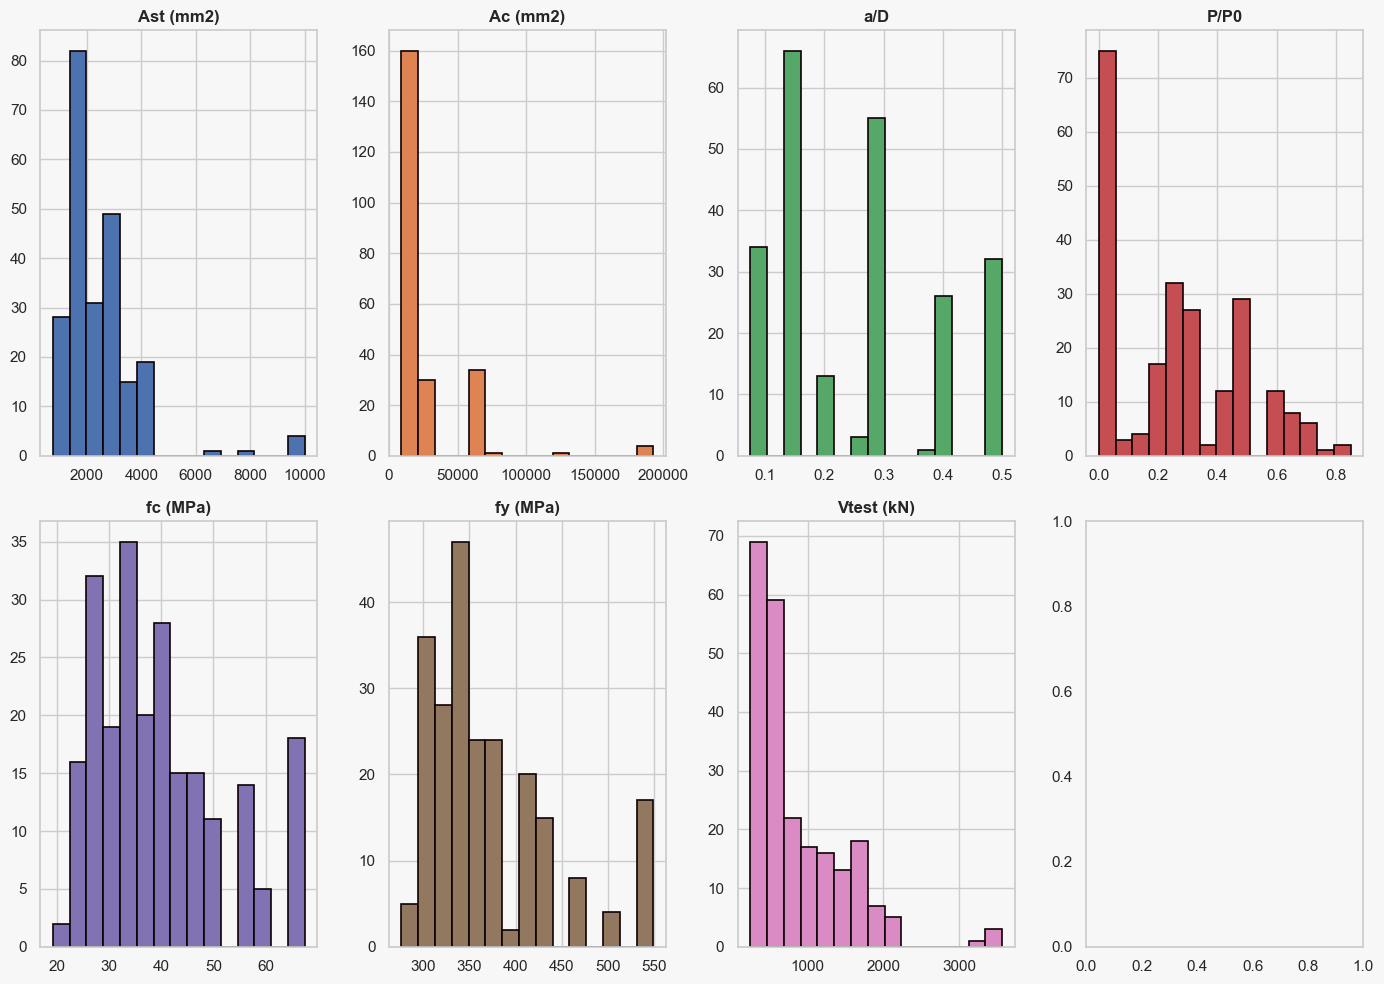

In [6]:
import matplotlib.pyplot as plt

# Plotting
bins = 15
fig, axes = plt.subplots(2, 4)
fig.set_size_inches(14, 10)
fig.patch.set_facecolor('#f7f7f7')  # Set background color

for ax in axes.flatten():
    ax.set_facecolor('#f7f7f7')  # Set background color
    ax.grid(False)  # Remove grid

for i, (col, ax) in enumerate(zip(data.columns, axes.flatten())):
    data[col].hist(bins=bins, ax=ax, color=f'C{i}', edgecolor='#0d0103', linewidth=1.2)
    ax.set_title(col, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np

# Basic statistics
desc = data.describe().T  # Transpose for better readability

# Add additional statistical parameters
desc['median'] = data.median()
desc['mode'] = data.mode().iloc[0]  # mode() can return multiple rows
desc['skewness'] = data.skew()
desc['kurtosis'] = data.kurt()

# Round for better readability
desc = desc.round(3)

# Display summary table
print("\n📊 Detailed Statistical Summary:")
print(desc)

# Optionally export to CSV
desc.to_csv("data_statistical_summary.csv")


📊 Detailed Statistical Summary:
            count       mean        std       min        25%        50%  \
Ast (mm2)   230.0   2433.860   1486.741   741.040   1526.040   2191.790   
Ac (mm2)    230.0  29263.513  29151.266  9116.560  17436.110  19855.070   
a/D         230.0      0.259      0.136     0.075      0.140      0.250   
P/P0        230.0      0.255      0.223     0.000      0.000      0.253   
fc (MPa)    230.0     39.313     12.116    19.200     29.500     35.990   
fy (MPa)    230.0    373.091     66.634   276.800    330.000    346.950   
Vtest (kN)  230.0    870.842    602.416   240.000    435.625    627.500   

                  75%        max     median      mode  skewness  kurtosis  
Ast (mm2)    3184.910   10002.40   2191.790   3184.91     2.645    10.537  
Ac (mm2)    25164.200  192669.84  19855.070  67497.32     3.529    15.638  
a/D             0.386       0.50      0.250      0.30     0.496    -1.058  
P/P0            0.453       0.85      0.253      0.00     0.41

In [8]:
# split into input (X) and output (Y) variables
X = data.drop(['Vtest (kN)'], axis =1)
Y = data['Vtest (kN)']

print(X.shape)
print(Y.shape)

(230, 6)
(230,)


In [9]:
# randomly spliting the database into training-testing sets as 70%-30%
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# normalizing the data sets
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Different machine learning (ML) models are adopted below to predict the shear strength of concrete-filled steel tubes (CFSTs). The performances of these ML models are evaluated and compared with each other.

# PSO-CatBoost

In [10]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from pyswarm import pso  # Particle Swarm Optimization


In [11]:
def objective_function_catboost(params):
    iterations = int(params[0])
    depth = int(params[1])
    learning_rate = params[2]

    model = CatBoostRegressor(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        verbose=0,
        random_seed=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = mean_squared_error(y_test, preds, squared=False)
    return rmse


In [12]:
# Define bounds: [iterations, depth, learning_rate]
lb = [100, 3, 0.01]  # lower bounds
ub = [1000, 10, 0.3]  # upper bounds

best_params, best_rmse = pso(objective_function_catboost, lb, ub, swarmsize=15, maxiter=10)


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function

Stopping search: maximum iterations reached --> 10


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [13]:
# Extract best parameters
best_iterations = int(best_params[0])
best_depth = int(best_params[1])
best_learning_rate = best_params[2]

final_model = CatBoostRegressor(
    iterations=best_iterations,
    depth=best_depth,
    learning_rate=best_learning_rate,
    verbose=0,
    random_seed=42
)

final_model.fit(X_train, y_train)

# Prediction and evaluation
y_pred = final_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("Best Parameters from PSO:")
print(f"Iterations: {best_iterations}, Depth: {best_depth}, Learning Rate: {best_learning_rate:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


Best Parameters from PSO:
Iterations: 800, Depth: 3, Learning Rate: 0.0609
R² Score: 0.9863
RMSE: 67.9279


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [14]:
#predicted
cat_ypred_train = final_model.predict(X_train)
cat_ypred_test = final_model.predict(X_test)

In [15]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate R-squared (R²) for both training and testing sets
r2_train = r2_score(y_train, cat_ypred_train)
r2_test = r2_score(y_test, cat_ypred_test)

# Calculate Root Mean Squared Error (RMSE) for both training and testing sets
rmse_train = np.sqrt(mean_squared_error(y_train, cat_ypred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, cat_ypred_test))

# Calculate Mean Absolute Error (MAE) for both training and testing sets
mae_train = mean_absolute_error(y_train, cat_ypred_train)
mae_test = mean_absolute_error(y_test, cat_ypred_test)

# Calculate Mean Absolute Percentage Error (MAPE) for both training and testing sets
mape_train = np.mean(np.abs((y_train - cat_ypred_train) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - cat_ypred_test) / y_test)) * 100

# Calculate Nash-Sutcliffe Efficiency (NSE) for both training and testing sets
nse_train = 1 - (np.sum((y_train - cat_ypred_train) ** 2) / np.sum((y_train - np.mean(y_train)) ** 2))
nse_test = 1 - (np.sum((y_test - cat_ypred_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

# Display the calculated goodness-of-fit values
print(f"R-squared (R²) - Training: {r2_train:.4f}")
print(f"R-squared (R²) - Testing: {r2_test:.4f}")
print(f"Root Mean Squared Error (RMSE) - Training: {rmse_train:.4f}")
print(f"Root Mean Squared Error (RMSE) - Testing: {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE) - Training: {mae_train:.4f}")
print(f"Mean Absolute Error (MAE) - Testing: {mae_test:.4f}")
print(f"Mean Absolute Percentage Error (MAPE) - Training: {mape_train:.4f}%")
print(f"Mean Absolute Percentage Error (MAPE) - Testing: {mape_test:.4f}%")
print(f"Nash-Sutcliffe Efficiency (NSE) - Training: {nse_train:.4f}")
print(f"Nash-Sutcliffe Efficiency (NSE) - Testing: {nse_test:.4f}")

R-squared (R²) - Training: 0.9984
R-squared (R²) - Testing: 0.9863
Root Mean Squared Error (RMSE) - Training: 24.3595
Root Mean Squared Error (RMSE) - Testing: 67.9279
Mean Absolute Error (MAE) - Training: 17.9581
Mean Absolute Error (MAE) - Testing: 46.2694
Mean Absolute Percentage Error (MAPE) - Training: 2.5597%
Mean Absolute Percentage Error (MAPE) - Testing: 5.8641%
Nash-Sutcliffe Efficiency (NSE) - Training: 0.9984
Nash-Sutcliffe Efficiency (NSE) - Testing: 0.9863


In [13]:
## convert your array into a dataframe
df_pred = pd.DataFrame (cat_ypred_train)
df_pred.to_excel('Pred_PSO-Cat_train.xlsx')
## convert your array into a dataframe
df_pred = pd.DataFrame (cat_ypred_test)
df_pred.to_excel('Pred_PSO-Cat_test.xlsx')

In [14]:
#save train dataset
df = pd.DataFrame (y_train)
df.to_excel('train_data.xlsx')
#save train dataset
df = pd.DataFrame (y_test)
df.to_excel('test_data.xlsx')


PSO-RF 



In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from pyswarm import pso


def objective_function(params):
    n_estimators = int(params[0])
    max_depth = int(params[1])
    min_samples_split = int(params[2])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    # 5-fold cross-validation
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    return -scores.mean() 

# --- PSO bounds: [n_estimators, max_depth, min_samples_split] ---
lb = [50, 3, 2]
ub = [300, 20, 20]

# --- Run PSO ---
best_params, best_score = pso(objective_function, lb, ub, swarmsize=15, maxiter=10)

# --- Extract best parameters ---
best_n_estimators = int(best_params[0])
best_max_depth = int(best_params[1])
best_min_samples_split = int(best_params[2])

print(f"Best Parameters from PSO:")
print(f"n_estimators = {best_n_estimators}")
print(f"max_depth = {best_max_depth}")
print(f"min_samples_split = {best_min_samples_split}")

# --- Train final RF model ---
final_model = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    random_state=42
)
final_model.fit(X_train, y_train)

# --- Predict and evaluate on test set ---
y_pred = final_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest R² Score: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")


Stopping search: maximum iterations reached --> 10
Best Parameters from PSO:
n_estimators = 75
max_depth = 8
min_samples_split = 2

Test R² Score: 0.9789
Test RMSE: 84.2934


In [16]:
#predicted
rf_ypred_train = final_model.predict(X_train)
rf_ypred_test = final_model.predict(X_test)

In [17]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate R-squared (R²) for both training and testing sets
r2_train = r2_score(y_train, rf_ypred_train)
r2_test = r2_score(y_test, rf_ypred_test)

# Calculate Root Mean Squared Error (RMSE) for both training and testing sets
rmse_train = np.sqrt(mean_squared_error(y_train, rf_ypred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, rf_ypred_test))

# Calculate Mean Absolute Error (MAE) for both training and testing sets
mae_train = mean_absolute_error(y_train, rf_ypred_train)
mae_test = mean_absolute_error(y_test, rf_ypred_test)

# Calculate Mean Absolute Percentage Error (MAPE) for both training and testing sets
mape_train = np.mean(np.abs((y_train - rf_ypred_train) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - rf_ypred_test) / y_test)) * 100

# Calculate Nash-Sutcliffe Efficiency (NSE) for both training and testing sets
nse_train = 1 - (np.sum((y_train - rf_ypred_train) ** 2) / np.sum((y_train - np.mean(y_train)) ** 2))
nse_test = 1 - (np.sum((y_test - rf_ypred_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

# Display the calculated goodness-of-fit values
print(f"R-squared (R²) - Training: {r2_train:.4f}")
print(f"R-squared (R²) - Testing: {r2_test:.4f}")
print(f"Root Mean Squared Error (RMSE) - Training: {rmse_train:.4f}")
print(f"Root Mean Squared Error (RMSE) - Testing: {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE) - Training: {mae_train:.4f}")
print(f"Mean Absolute Error (MAE) - Testing: {mae_test:.4f}")
print(f"Mean Absolute Percentage Error (MAPE) - Training: {mape_train:.4f}%")
print(f"Mean Absolute Percentage Error (MAPE) - Testing: {mape_test:.4f}%")
print(f"Nash-Sutcliffe Efficiency (NSE) - Training: {nse_train:.4f}")
print(f"Nash-Sutcliffe Efficiency (NSE) - Testing: {nse_test:.4f}")

R-squared (R²) - Training: 0.9933
R-squared (R²) - Testing: 0.9789
Root Mean Squared Error (RMSE) - Training: 49.7676
Root Mean Squared Error (RMSE) - Testing: 84.2934
Mean Absolute Error (MAE) - Training: 31.2667
Mean Absolute Error (MAE) - Testing: 55.8257
Mean Absolute Percentage Error (MAPE) - Training: 3.6933%
Mean Absolute Percentage Error (MAPE) - Testing: 6.8307%
Nash-Sutcliffe Efficiency (NSE) - Training: 0.9933
Nash-Sutcliffe Efficiency (NSE) - Testing: 0.9789


In [18]:
## convert your array into a dataframe
df_pred = pd.DataFrame (rf_ypred_train)
df_pred.to_excel('Pred_PSO-RF_train.xlsx')
## convert your array into a dataframe
df_pred = pd.DataFrame (rf_ypred_test)
df_pred.to_excel('Pred_PSO-RF_test.xlsx')

# BO-CatBoost

In [19]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from bayes_opt import BayesianOptimization


In [20]:
def catboost_evaluate(iterations, depth, learning_rate):
    params = {
        'iterations': int(iterations),
        'depth': int(depth),
        'learning_rate': learning_rate,
        'verbose': 0,
        'random_seed': 42
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)
    return -rmse  # negative because BO maximizes the objective


In [21]:
# Define search bounds
pbounds = {
    'iterations': (100, 1000),
    'depth': (3, 10),
    'learning_rate': (0.01, 0.3)
}

# Optimizer initialization
optimizer = BayesianOptimization(
    f=catboost_evaluate,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

# Run optimization
optimizer.maximize(init_points=5, n_iter=15)


|   iter    |  target   |   depth   | iterat... | learni... |
-------------------------------------------------------------


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 1         | -107.6    | 5.622     | 955.6     | 0.2223    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 2         | -153.0    | 7.191     | 240.4     | 0.05524   |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 3         | -100.7    | 3.407     | 879.6     | 0.1843    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 4         | -145.6    | 7.957     | 118.5     | 0.2913    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 5         | -147.5    | 8.827     | 291.1     | 0.06273   |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 6         | -201.3    | 10.0      | 658.8     | 0.3       |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 7         | -151.9    | 4.082     | 878.3     | 0.2883    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 8         | -112.2    | 5.277     | 531.2     | 0.05141   |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 9         | -134.2    | 9.601     | 431.1     | 0.07418   |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 10        | -160.3    | 9.259     | 875.4     | 0.1298    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 11        | -116.1    | 5.326     | 711.9     | 0.2893    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 12        | -78.39    | 3.661     | 821.1     | 0.1828    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 13        | -104.1    | 3.605     | 821.1     | 0.229     |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 14        | -104.0    | 5.525     | 955.7     | 0.2356    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 15        | -78.93    | 3.935     | 821.7     | 0.1665    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 16        | -110.3    | 5.158     | 875.0     | 0.03721   |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 17        | -113.9    | 4.32      | 822.0     | 0.1528    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 18        | -121.4    | 4.877     | 329.8     | 0.1563    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


| 19        | -127.6    | 7.287     | 155.4     | 0.1332    |
| 20        | -119.1    | 4.007     | 821.9     | 0.2192    |


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [22]:
# Extract best parameters
best_params = optimizer.max['params']
best_iterations = int(best_params['iterations'])
best_depth = int(best_params['depth'])
best_lr = best_params['learning_rate']

# Train final model
final_model = CatBoostRegressor(
    iterations=best_iterations,
    depth=best_depth,
    learning_rate=best_lr,
    verbose=0,
    random_seed=42
)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("\n🔍 Best Hyperparameters from BO:")
print(f"Iterations: {best_iterations}")
print(f"Depth: {best_depth}")
print(f"Learning Rate: {best_lr:.4f}")
print(f"\n✅ R² Score: {r2:.4f}")
print(f"✅ RMSE: {rmse:.4f}")



🔍 Best Hyperparameters from BO:
Iterations: 821
Depth: 3
Learning Rate: 0.1828

✅ R² Score: 0.9817
✅ RMSE: 78.3947


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [25]:
#predicted
cat_ypred_train = final_model.predict(X_train)
cat_ypred_test = final_model.predict(X_test)

In [26]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate R-squared (R²) for both training and testing sets
r2_train = r2_score(y_train, cat_ypred_train)
r2_test = r2_score(y_test, cat_ypred_test)

# Calculate Root Mean Squared Error (RMSE) for both training and testing sets
rmse_train = np.sqrt(mean_squared_error(y_train, cat_ypred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, cat_ypred_test))

# Calculate Mean Absolute Error (MAE) for both training and testing sets
mae_train = mean_absolute_error(y_train, cat_ypred_train)
mae_test = mean_absolute_error(y_test, cat_ypred_test)

# Calculate Mean Absolute Percentage Error (MAPE) for both training and testing sets
mape_train = np.mean(np.abs((y_train - cat_ypred_train) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - cat_ypred_test) / y_test)) * 100

# Calculate Nash-Sutcliffe Efficiency (NSE) for both training and testing sets
nse_train = 1 - (np.sum((y_train - cat_ypred_train) ** 2) / np.sum((y_train - np.mean(y_train)) ** 2))
nse_test = 1 - (np.sum((y_test - cat_ypred_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

# Display the calculated goodness-of-fit values
print(f"R-squared (R²) - Training: {r2_train:.4f}")
print(f"R-squared (R²) - Testing: {r2_test:.4f}")
print(f"Root Mean Squared Error (RMSE) - Training: {rmse_train:.4f}")
print(f"Root Mean Squared Error (RMSE) - Testing: {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE) - Training: {mae_train:.4f}")
print(f"Mean Absolute Error (MAE) - Testing: {mae_test:.4f}")
print(f"Mean Absolute Percentage Error (MAPE) - Training: {mape_train:.4f}%")
print(f"Mean Absolute Percentage Error (MAPE) - Testing: {mape_test:.4f}%")
print(f"Nash-Sutcliffe Efficiency (NSE) - Training: {nse_train:.4f}")
print(f"Nash-Sutcliffe Efficiency (NSE) - Testing: {nse_test:.4f}")

R-squared (R²) - Training: 0.9996
R-squared (R²) - Testing: 0.9817
Root Mean Squared Error (RMSE) - Training: 12.5550
Root Mean Squared Error (RMSE) - Testing: 78.3947
Mean Absolute Error (MAE) - Training: 8.5594
Mean Absolute Error (MAE) - Testing: 55.6131
Mean Absolute Percentage Error (MAPE) - Training: 1.2596%
Mean Absolute Percentage Error (MAPE) - Testing: 7.1296%
Nash-Sutcliffe Efficiency (NSE) - Training: 0.9996
Nash-Sutcliffe Efficiency (NSE) - Testing: 0.9817


In [27]:
## convert your array into a dataframe
df_pred = pd.DataFrame (cat_ypred_train)
df_pred.to_excel('Pred_BO-Cat_train.xlsx')
## convert your array into a dataframe
df_pred = pd.DataFrame (cat_ypred_test)
df_pred.to_excel('Pred_BO-Cat_test.xlsx')

BO-RF

In [28]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from bayes_opt import BayesianOptimization

def rf_cv(n_estimators, max_depth, min_samples_split):
    n_estimators = int(n_estimators)
    max_depth = int(max_depth)
    min_samples_split = int(min_samples_split)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    return scores.mean()

# --- Define the search space ---
pbounds = {
    'n_estimators': (50, 300),
    'max_depth': (3, 20),
    'min_samples_split': (2, 20)
}

# --- Bayesian Optimization ---
optimizer = BayesianOptimization(f=rf_cv, pbounds=pbounds, random_state=42, verbose=2)
optimizer.maximize(init_points=5, n_iter=15)

# --- Get the best parameters ---
best_params = optimizer.max['params']
best_n_estimators = int(best_params['n_estimators'])
best_max_depth = int(best_params['max_depth'])
best_min_samples_split = int(best_params['min_samples_split'])

print(f"\nBest Parameters from BO:")
print(f"n_estimators = {best_n_estimators}")
print(f"max_depth = {best_max_depth}")
print(f"min_samples_split = {best_min_samples_split}")

# --- Train final model ---
final_model = RandomForestRegressor(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    random_state=42
)
final_model.fit(X_train, y_train)

# --- Predict and evaluate ---
y_pred = final_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nFinal Test R² Score: {r2:.4f}")
print(f"Final Test RMSE: {rmse:.4f}")


|   iter    |  target   | max_depth | min_sa... | n_esti... |
-------------------------------------------------------------
| 1         | 0.8938    | 9.367     | 19.11     | 233.0     |
| 2         | 0.9464    | 13.18     | 4.808     | 89.0      |
| 3         | 0.8756    | 3.987     | 17.59     | 200.3     |
| 4         | 0.9485    | 15.04     | 2.371     | 292.5     |
| 5         | 0.9424    | 17.15     | 5.822     | 95.46     |
| 6         | 0.8893    | 20.0      | 20.0      | 50.0      |
| 7         | 0.9431    | 13.05     | 5.862     | 88.01     |
| 8         | 0.8831    | 3.0       | 2.0       | 113.4     |
| 9         | 0.8938    | 19.81     | 19.39     | 299.2     |
| 10        | 0.8823    | 3.907     | 2.513     | 283.0     |
| 11        | 0.9486    | 20.0      | 2.0       | 300.0     |
| 12        | 0.9487    | 8.772     | 2.585     | 299.7     |
| 13        | 0.8811    | 3.653     | 2.282     | 73.51     |
| 14        | 0.8887    | 8.868     | 20.0      | 96.05     |
| 15    

In [29]:
#predicted
rf_ypred_train = final_model.predict(X_train)
rf_ypred_test = final_model.predict(X_test)

In [30]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate R-squared (R²) for both training and testing sets
r2_train = r2_score(y_train, rf_ypred_train)
r2_test = r2_score(y_test, rf_ypred_test)

# Calculate Root Mean Squared Error (RMSE) for both training and testing sets
rmse_train = np.sqrt(mean_squared_error(y_train, rf_ypred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, rf_ypred_test))

# Calculate Mean Absolute Error (MAE) for both training and testing sets
mae_train = mean_absolute_error(y_train, rf_ypred_train)
mae_test = mean_absolute_error(y_test, rf_ypred_test)

# Calculate Mean Absolute Percentage Error (MAPE) for both training and testing sets
mape_train = np.mean(np.abs((y_train - rf_ypred_train) / y_train)) * 100
mape_test = np.mean(np.abs((y_test - rf_ypred_test) / y_test)) * 100

# Calculate Nash-Sutcliffe Efficiency (NSE) for both training and testing sets
nse_train = 1 - (np.sum((y_train - rf_ypred_train) ** 2) / np.sum((y_train - np.mean(y_train)) ** 2))
nse_test = 1 - (np.sum((y_test - rf_ypred_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

# Display the calculated goodness-of-fit values
print(f"R-squared (R²) - Training: {r2_train:.4f}")
print(f"R-squared (R²) - Testing: {r2_test:.4f}")
print(f"Root Mean Squared Error (RMSE) - Training: {rmse_train:.4f}")
print(f"Root Mean Squared Error (RMSE) - Testing: {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE) - Training: {mae_train:.4f}")
print(f"Mean Absolute Error (MAE) - Testing: {mae_test:.4f}")
print(f"Mean Absolute Percentage Error (MAPE) - Training: {mape_train:.4f}%")
print(f"Mean Absolute Percentage Error (MAPE) - Testing: {mape_test:.4f}%")
print(f"Nash-Sutcliffe Efficiency (NSE) - Training: {nse_train:.4f}")
print(f"Nash-Sutcliffe Efficiency (NSE) - Testing: {nse_test:.4f}")

R-squared (R²) - Training: 0.9944
R-squared (R²) - Testing: 0.9764
Root Mean Squared Error (RMSE) - Training: 45.8405
Root Mean Squared Error (RMSE) - Testing: 88.9824
Mean Absolute Error (MAE) - Training: 27.8933
Mean Absolute Error (MAE) - Testing: 60.6757
Mean Absolute Percentage Error (MAPE) - Training: 3.0970%
Mean Absolute Percentage Error (MAPE) - Testing: 7.1063%
Nash-Sutcliffe Efficiency (NSE) - Training: 0.9944
Nash-Sutcliffe Efficiency (NSE) - Testing: 0.9764


In [31]:
## convert your array into a dataframe
df_pred = pd.DataFrame (rf_ypred_train)
df_pred.to_excel('Pred_BO-RF_train.xlsx')
## convert your array into a dataframe
df_pred = pd.DataFrame (rf_ypred_test)
df_pred.to_excel('Pred_BO-RF_test.xlsx')

# Interpretation of the  model using SHAP

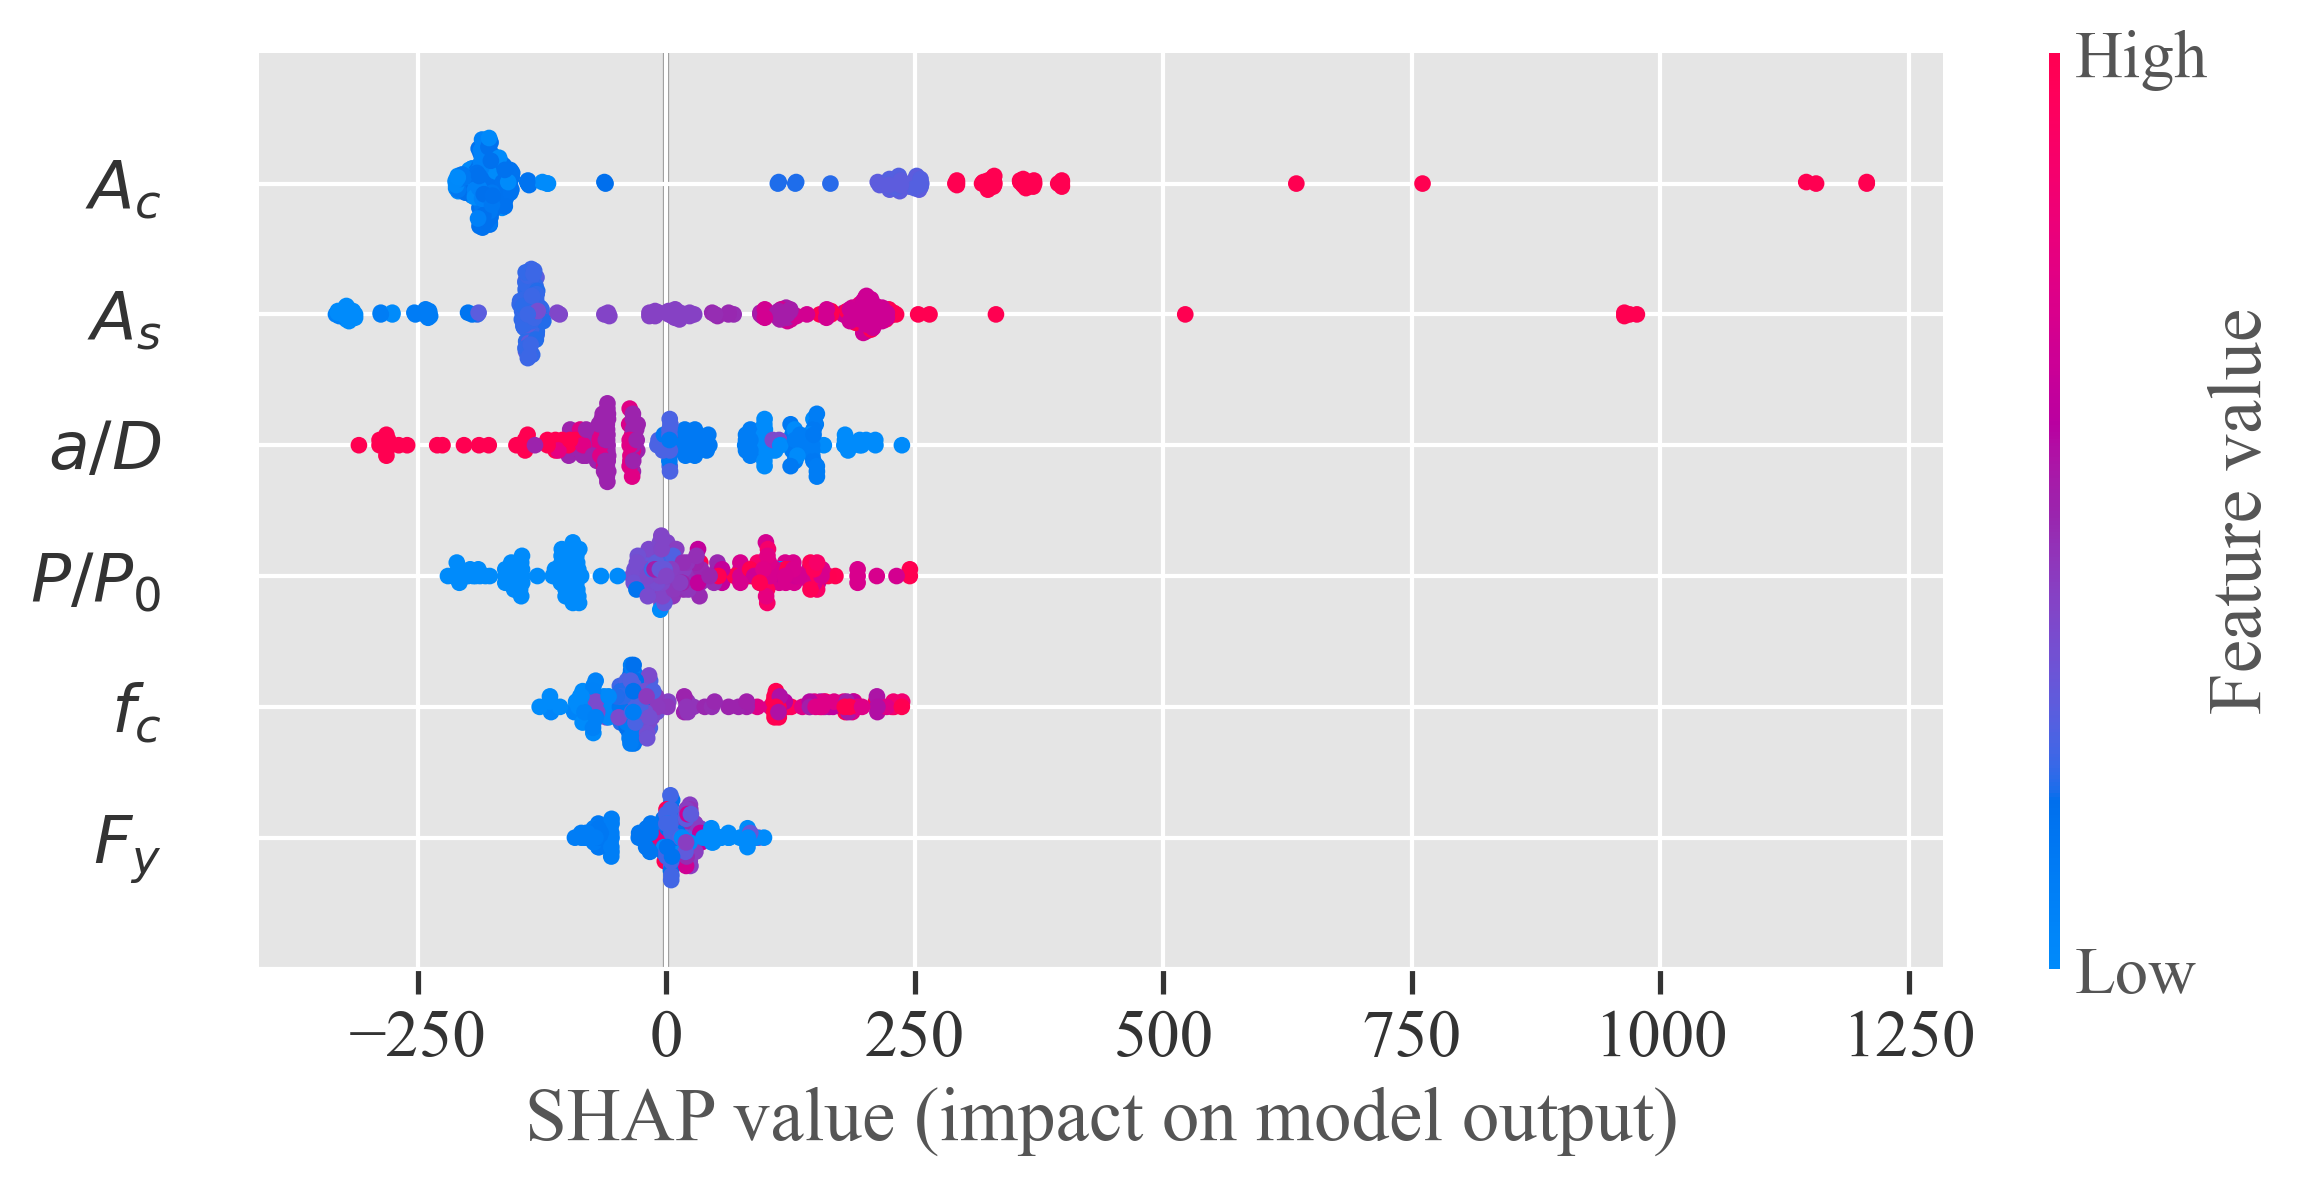

In [14]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Use a safe built-in style
plt.style.use('ggplot')
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.dpi"] = 300

# Define LaTeX-style feature names
featureName = [r'$A_{s}$', r'$A_{c}$', r'$a/D$', r'$P/P_{0}$', r'$f_{c}$', r'$F_{y}$']

# Prepare SHAP input
X_shap = scaler.transform(X)
X_shap_df = pd.DataFrame(X_shap, columns=X.columns)

# SHAP explainer and values
shap.initjs()
explainer = shap.Explainer(final_model)
shap_values = explainer(X_shap_df)

# Plot
plt.figure()
shap.summary_plot(shap_values, X_shap_df, feature_names=featureName, show=False)

fig = plt.gcf()
fig.axes[0].tick_params(labelsize=16)
fig.axes[0].xaxis.label.set_size(18)
fig.axes[-1].tick_params(labelsize=16)
fig.axes[-1].yaxis.label.set_size(18)


plt.show()

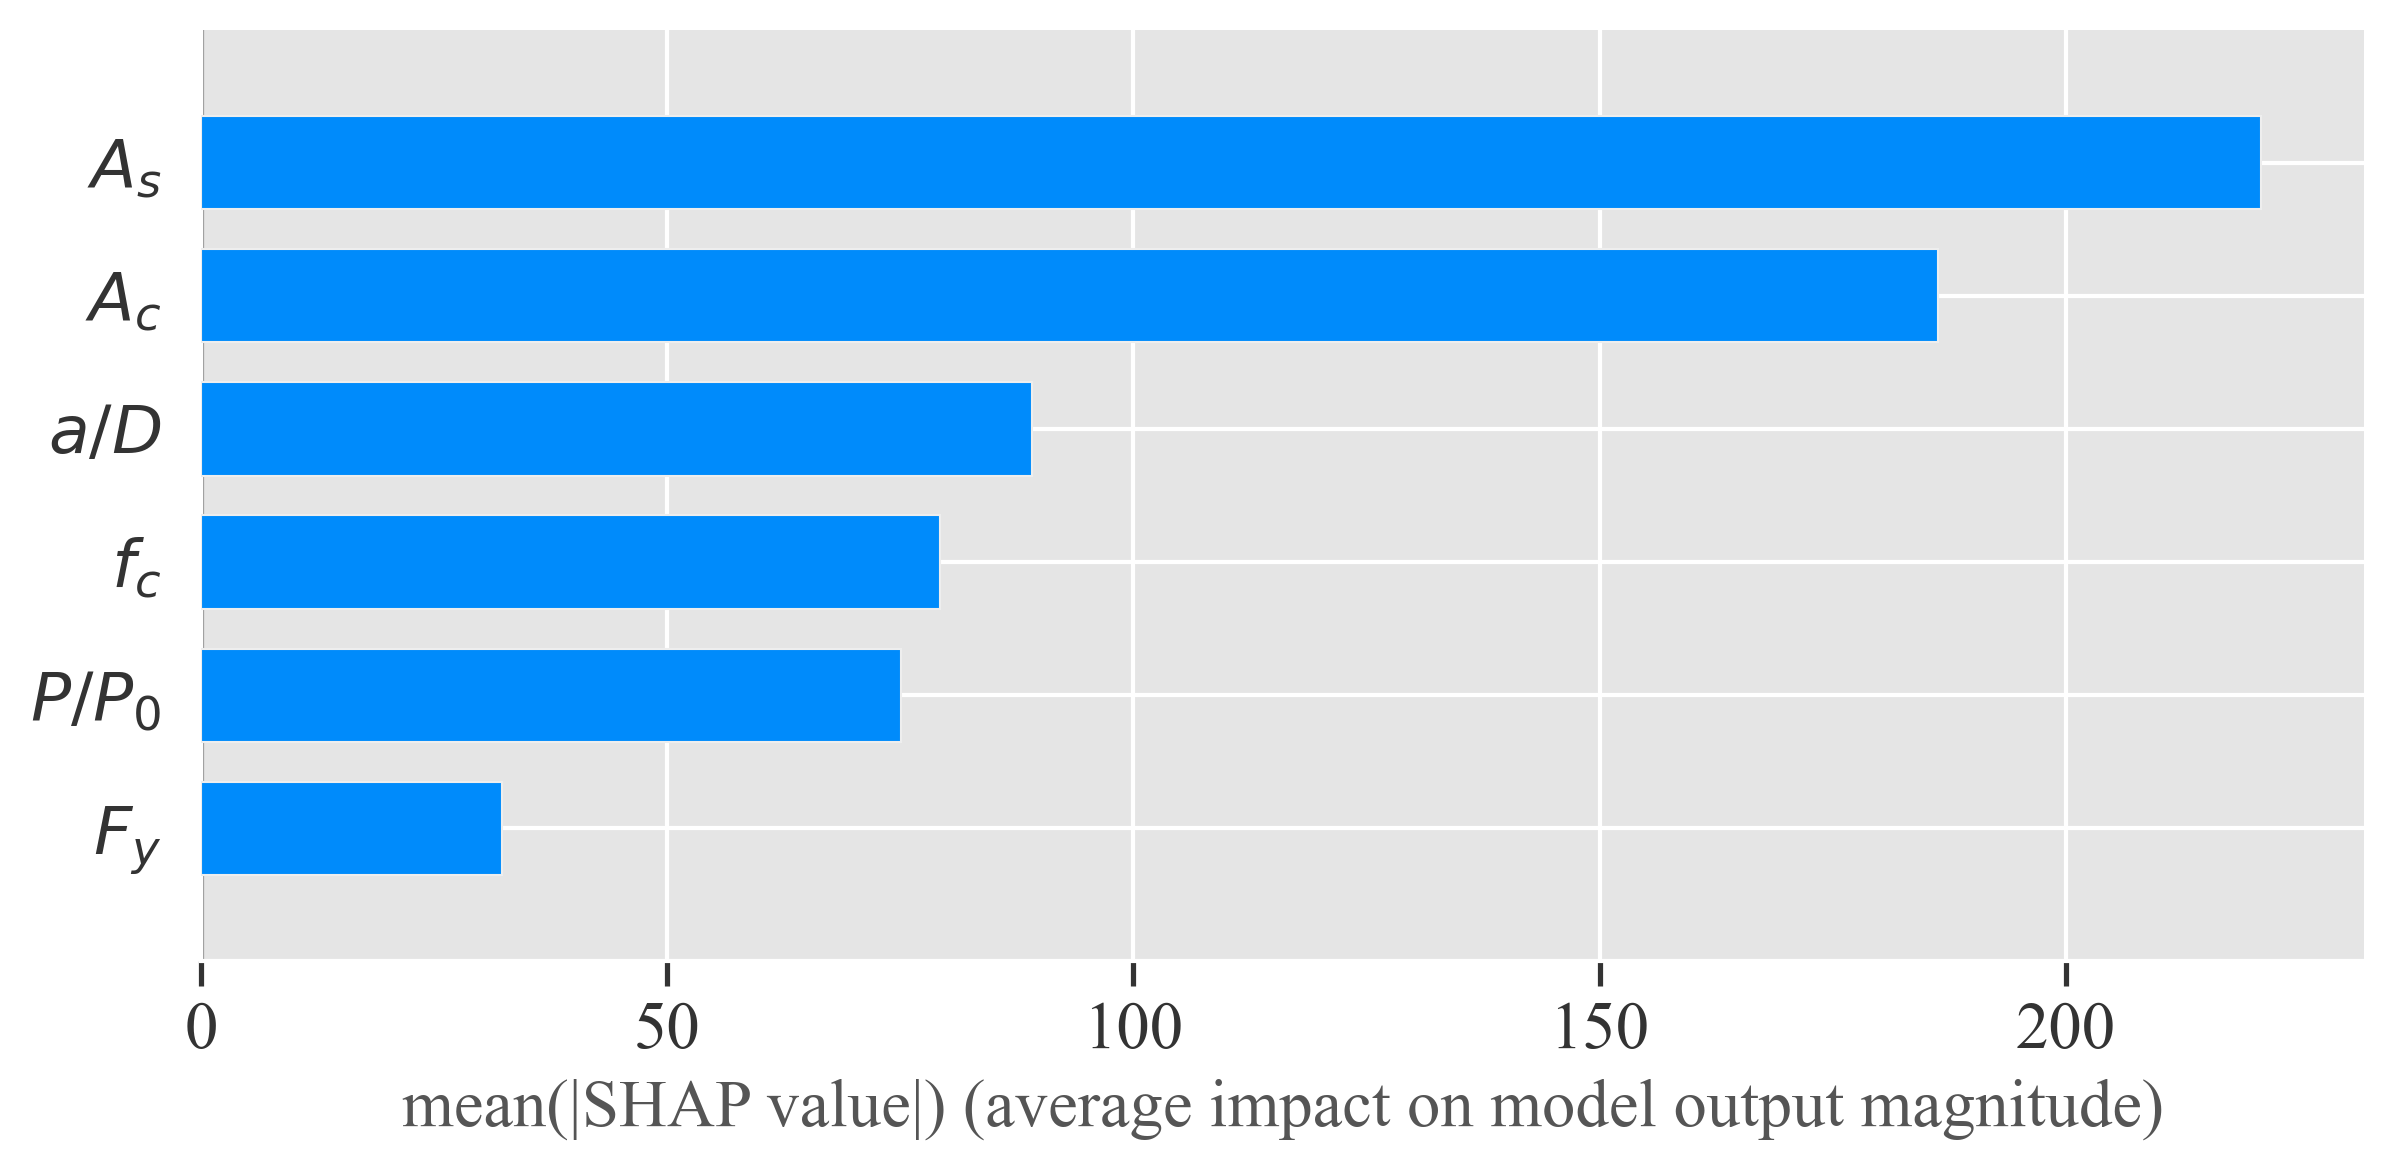

In [16]:
shap.summary_plot(shap_values, X_shap, feature_names=featureName, show=False,  plot_type="bar")

fig, ax = plt.gcf(), plt.gca()
ax.xaxis.label.set_size(16)
ax.tick_params(axis='both', labelsize=16)

plt.savefig('feature importance.eps', format='eps')
plt.show()

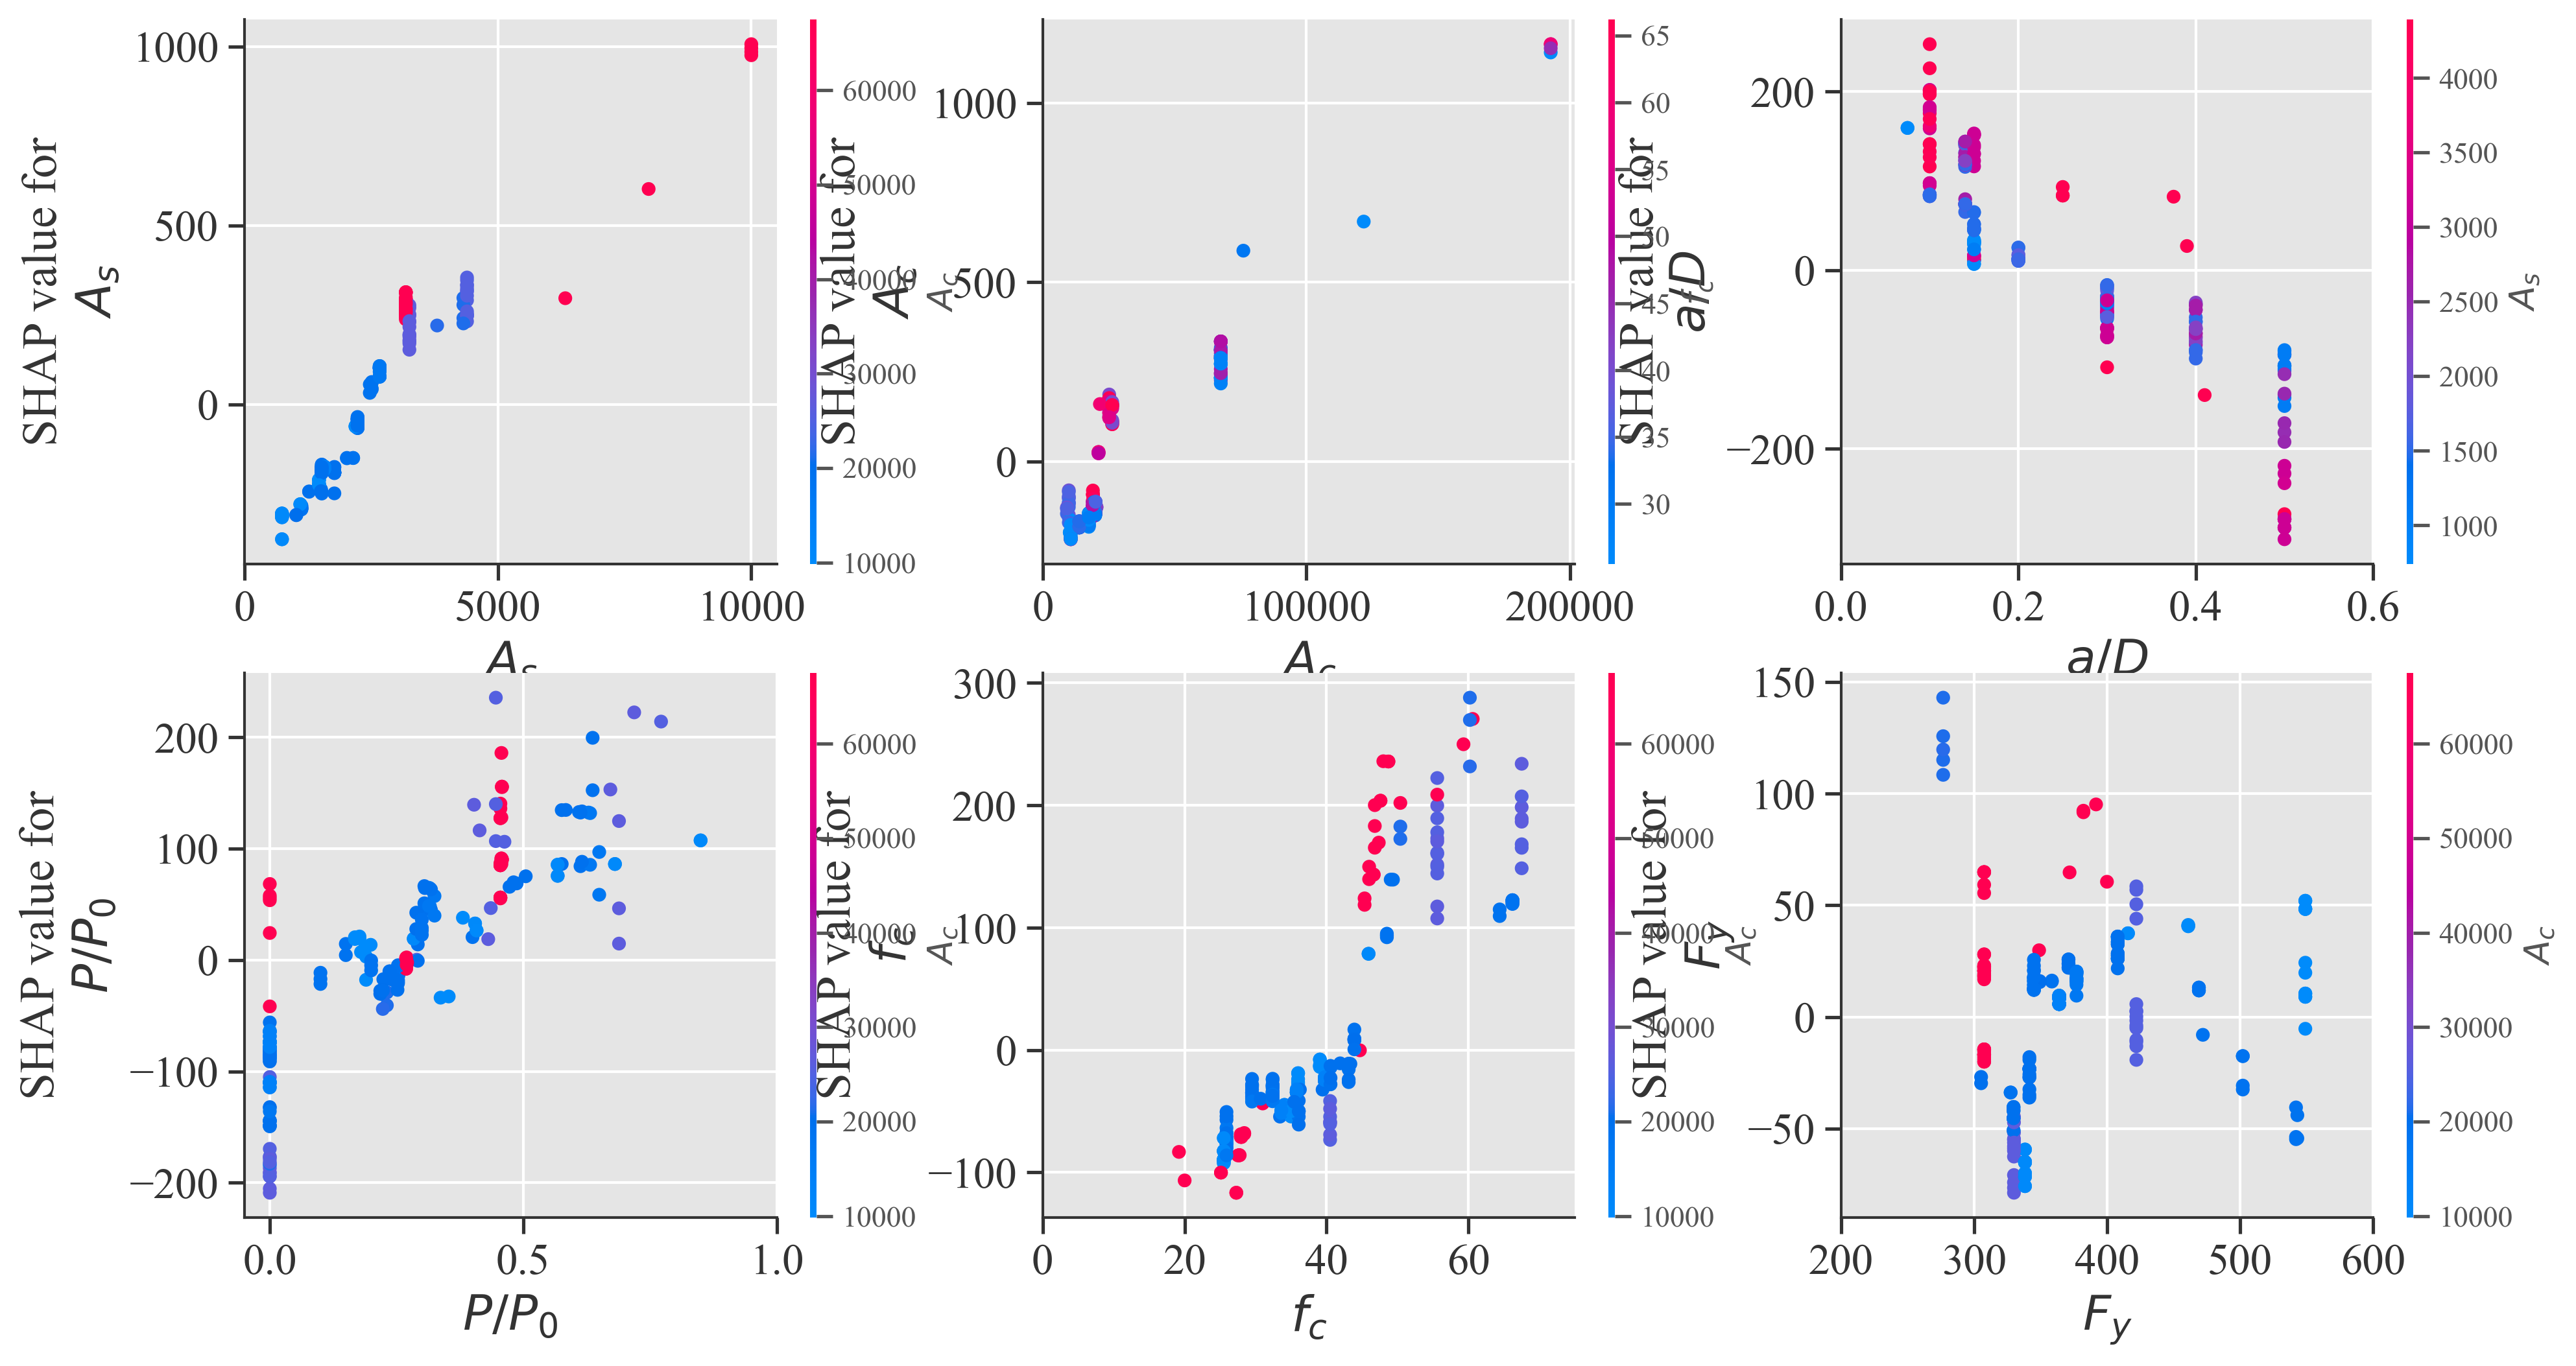

In [20]:
import matplotlib.pyplot as plt
import shap
import numpy as np

# Convert shap_values to NumPy array if using shap.Explainer
shap_vals_array = shap_values.values if hasattr(shap_values, "values") else shap_values

# Create 2x3 subplots
fig_dep, axs_dep = plt.subplots(2, 3, figsize=(15, 8))
axs_dep = axs_dep.flatten()  # Flatten for easier indexing

plt.rcParams['font.size'] = 22

# Feature dependence plots with custom axes
shap.dependence_plot(0, shap_vals_array, X, display_features=X_shap, feature_names=featureName,
                     show=False, dot_size=26, xmin=0, ax=axs_dep[0])
shap.dependence_plot(1, shap_vals_array, X, display_features=X_shap, feature_names=featureName,
                     show=False, dot_size=26, ax=axs_dep[1], interaction_index=4)
shap.dependence_plot(2, shap_vals_array, X, display_features=X_shap, feature_names=featureName,
                     show=False, dot_size=26, xmin=0, xmax=0.6, ax=axs_dep[2])
shap.dependence_plot(3, shap_vals_array, X, display_features=X_shap, feature_names=featureName,
                     show=False, dot_size=26, xmax=1, ax=axs_dep[3])
shap.dependence_plot(4, shap_vals_array, X, display_features=X_shap, feature_names=featureName,
                     show=False, dot_size=26, xmin=0, xmax=75, ax=axs_dep[4])
shap.dependence_plot(5, shap_vals_array, X, display_features=X_shap, feature_names=featureName,
                     show=False, dot_size=26, xmin=200, xmax=600, ax=axs_dep[5])

# Format each subplot
for ax in axs_dep:
    ax.tick_params(axis='both', labelsize=16)
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)
plt.show()

In [17]:
import joblib

In [18]:
# Step 5: Save the model and scaler
joblib.dump(final_model, 'final_model.joblib')  # Save the trained XGBoost model
joblib.dump(scaler, 'scaler.joblib')  # Save the scaler

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [ ]:
# ============================================================


import tkinter as tk
from tkinter import messagebox
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Matplotlib Configuration
# -------------------------------
plt.style.use('ggplot')
plt.rcParams["font.family"] = "Times New Roman"

# -------------------------------
# Load Model and Scaler
# -------------------------------
try:
    final_model = joblib.load('final_model.joblib')
    scaler = joblib.load('scaler.joblib')
except Exception as e:
    root = tk.Tk()
    root.withdraw()
    messagebox.showerror("Model Error", f"Failed to load model or scaler:\n{e}")
    raise

# -------------------------------
# Feature Names (must match training data)
# -------------------------------
feature_names = [
    'Ast', 'Ac', 'a/D', 'P/P0', 'fc', 'fy'
]

# -------------------------------
# Initialize Main Window
# -------------------------------
root = tk.Tk()
root.title("Shear Strength Predictor GUI")
root.geometry("1250x950")
root.configure(bg="#E8F0FE")

# Create a canvas for layout
frame_canvas = tk.Canvas(root, bg="#E8F0FE", highlightthickness=0)
frame_canvas.pack(fill=tk.BOTH, expand=True)

# -------------------------------
# Helper: Create Label
# -------------------------------
def create_label(text, font, fg, bg, x, y):
    label = tk.Label(root, text=text, font=font, fg=fg, bg=bg)
    frame_canvas.create_window(x, y, anchor="w", window=label)
    return label

# -------------------------------

# -------------------------------
# Title & Input Section
# -------------------------------
create_label("Shear Strength Prediction",
             ('Helvetica', 24, 'bold'), '#FFFFFF', '#2C3E50', 420, 30)

create_label('Enter Input Parameter Values:',
             ('Helvetica', 18, 'bold'), '#000000', '#E8F0FE', 60, 100)

# -------------------------------
# Input Fields
# -------------------------------
entries = {}
start_y = 160
spacing_y = 55

for i, param in enumerate(feature_names):
    y = start_y + i * spacing_y
    create_label(param, ('Helvetica', 14, 'bold'), '#1B2631', '#E8F0FE', 60, y)
    entry = tk.Entry(root, font=('Helvetica', 14), bg='#FBFCFC', width=20,
                     highlightbackground='#1C2833', highlightthickness=1)
    frame_canvas.create_window(500, y, window=entry)
    entries[param] = entry

# -------------------------------
# Output Section
# -------------------------------
create_label("Prediction Output:",
             ('Helvetica', 18, 'bold'), '#000000', '#E8F0FE', 60, 750)

label_result = create_label("Shear Strength (MPa): --",
                            ('Helvetica', 18, 'bold'), '#B03A2E', '#E8F0FE', 350, 750)

# -------------------------------
# Prediction Function
# -------------------------------
def predict():
    try:
        input_values = []
        for param in feature_names:
            val = float(entries[param].get())
            if val <= 0:
                raise ValueError("All values must be positive.")
            input_values.append(val)

        input_scaled = scaler.transform([input_values])
        prediction = final_model.predict(input_scaled)
        label_result['text'] = f"Shear Strength = {prediction[0]:.2f} MPa"

        # Confirmation
        messagebox.showinfo("Prediction Successful",
                            f"Predicted Compressive Strength: {prediction[0]:.2f} MPa")

    except ValueError:
        messagebox.showerror("Input Error", "All fields must contain valid positive numbers.")
    except Exception as e:
        messagebox.showerror("Prediction Error", f"Prediction failed:\n{e}")

# -------------------------------
# Buttons
# -------------------------------
predict_button = tk.Button(root, text="Predict", font=('Helvetica', 16, 'bold'),
                           fg='white', bg='#2980B9', padx=25, pady=10, command=predict)
frame_canvas.create_window(850, 740, window=predict_button)

shap_button = tk.Button(root, text="Generate SHAP Plot", font=('Helvetica', 16, 'bold'),
                        fg='white', bg='#27AE60', padx=25, pady=10, command=load_data_and_plot)
frame_canvas.create_window(850, 680, window=shap_button)

# -------------------------------
# Run GUI
# -------------------------------
root.mainloop()


In [19]:
# ============================================================
# Shear Strength Prediction GUI (Without SHAP)
# ============================================================

import tkinter as tk
from tkinter import messagebox
import joblib
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Matplotlib (optional for future extensions)
# -------------------------------
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams["font.family"] = "Times New Roman"

# -------------------------------
# Load Model and Scaler
# -------------------------------
try:
    final_model = joblib.load('final_model.joblib')
    scaler = joblib.load('scaler.joblib')
except Exception as e:
    root = tk.Tk()
    root.withdraw()
    messagebox.showerror("Model Error", f"Failed to load model or scaler:\n{e}")
    raise

# -------------------------------
# Feature Names (must match training data)
# -------------------------------
feature_names = [
    'Ast', 'Ac', 'a/D', 'P/P0', 'fc', 'fy'
]

# -------------------------------
# Initialize Main Window
# -------------------------------
root = tk.Tk()
root.title("Shear Strength Predictor GUI")
root.geometry("1250x950")
root.configure(bg="#E8F0FE")

# Create a canvas for layout
frame_canvas = tk.Canvas(root, bg="#E8F0FE", highlightthickness=0)
frame_canvas.pack(fill=tk.BOTH, expand=True)

# -------------------------------
# Helper: Create Label
# -------------------------------
def create_label(text, font, fg, bg, x, y):
    label = tk.Label(root, text=text, font=font, fg=fg, bg=bg)
    frame_canvas.create_window(x, y, anchor="w", window=label)
    return label

# -------------------------------
# Title & Input Section
# -------------------------------
create_label("Shear Strength Prediction",
             ('Helvetica', 24, 'bold'), '#FFFFFF', '#2C3E50', 420, 30)

create_label('Enter Input Parameter Values:',
             ('Helvetica', 18, 'bold'), '#000000', '#E8F0FE', 60, 100)

# -------------------------------
# Input Fields
# -------------------------------
entries = {}
start_y = 160
spacing_y = 55

for i, param in enumerate(feature_names):
    y = start_y + i * spacing_y
    create_label(param, ('Helvetica', 14, 'bold'), '#1B2631', '#E8F0FE', 60, y)
    entry = tk.Entry(root, font=('Helvetica', 14), bg='#FBFCFC', width=20,
                     highlightbackground='#1C2833', highlightthickness=1)
    frame_canvas.create_window(500, y, window=entry)
    entries[param] = entry

# -------------------------------
# Output Section
# -------------------------------
create_label("Prediction Output:",
             ('Helvetica', 18, 'bold'), '#000000', '#E8F0FE', 60, 750)

label_result = create_label("Shear Strength (MPa): --",
                            ('Helvetica', 18, 'bold'), '#B03A2E', '#E8F0FE', 350, 750)

# -------------------------------
# Prediction Function
# -------------------------------
def predict():
    try:
        input_values = []
        for param in feature_names:
            val = float(entries[param].get())
            if val <= 0:
                raise ValueError("All values must be positive.")
            input_values.append(val)

        input_scaled = scaler.transform([input_values])
        prediction = final_model.predict(input_scaled)
        label_result['text'] = f"Shear Strength = {prediction[0]:.2f} kN"

        messagebox.showinfo("Prediction Successful",
                            f"Predicted Shear Strength: {prediction[0]:.2f} kN")

    except ValueError:
        messagebox.showerror("Input Error", "All fields must contain valid positive numbers.")
    except Exception as e:
        messagebox.showerror("Prediction Error", f"Prediction failed:\n{e}")

# -------------------------------
# Predict Button
# -------------------------------
predict_button = tk.Button(root, text="Predict", font=('Helvetica', 16, 'bold'),
                           fg='white', bg='#2980B9', padx=25, pady=10, command=predict)
frame_canvas.create_window(850, 740, window=predict_button)

# -------------------------------
# Run GUI
# -------------------------------
root.mainloop()


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# Shear Strength Prediction GUI — Modern Layout
# ============================================================

import tkinter as tk
from tkinter import messagebox
import joblib
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Load Model and Scaler
# -------------------------------
try:
    final_model = joblib.load('final_model.joblib')
    scaler = joblib.load('scaler.joblib')
except Exception as e:
    root = tk.Tk()
    root.withdraw()
    messagebox.showerror("Model Error", f"Failed to load model or scaler:\n{e}")
    raise

# -------------------------------
# Feature Names (must match training data)
# -------------------------------
feature_names = ['Ast', 'Ac', 'a/D', 'P/P0', 'fc', 'fy']

# -------------------------------
# Initialize Main Window
# -------------------------------
root = tk.Tk()
root.title("Shear Strength Predictor")
root.geometry("1300x950")
root.configure(bg="#F5F7FA")  # Light background

# Create a frame for canvas
frame_canvas = tk.Canvas(root, bg="#F5F7FA", highlightthickness=0)
frame_canvas.pack(fill=tk.BOTH, expand=True)

# -------------------------------
# Helper: Create Label
# -------------------------------
def create_label(text, font, fg, bg, x, y):
    label = tk.Label(root, text=text, font=font, fg=fg, bg=bg)
    frame_canvas.create_window(x, y, anchor="w", window=label)
    return label

# -------------------------------
# Title
# -------------------------------
create_label("Shear Strength Prediction", ('Arial', 28, 'bold'),
             '#2C3E50', '#F5F7FA', 400, 30)

# -------------------------------
# Input Section Header
# -------------------------------
create_label("Enter Input Parameters:", ('Arial', 18, 'bold'),
             '#1B2631', '#F5F7FA', 60, 100)

# -------------------------------
# Input Fields
# -------------------------------
entries = {}
start_y = 160
spacing_y = 60

for i, param in enumerate(feature_names):
    y = start_y + i * spacing_y
    create_label(param, ('Arial', 14, 'bold'), '#34495E', '#F5F7FA', 60, y)
    entry = tk.Entry(root, font=('Arial', 14), bg='#FFFFFF', fg='#2C3E50',
                     width=20, bd=2, relief='groove')
    frame_canvas.create_window(500, y, window=entry)
    entries[param] = entry

# -------------------------------
# Output Section
# -------------------------------
create_label("Prediction Output:", ('Arial', 18, 'bold'),
             '#1B2631', '#F5F7FA', 60, 750)

label_result = create_label("Shear Strength (kN): --", ('Arial', 18, 'bold'),
                            '#C0392B', '#F5F7FA', 350, 750)

# -------------------------------
# Prediction Function
# -------------------------------
def predict():
    try:
        input_values = []
        for param in feature_names:
            val = float(entries[param].get())
            if val <= 0:
                raise ValueError("All values must be positive.")
            input_values.append(val)

        input_scaled = scaler.transform([input_values])
        prediction = final_model.predict(input_scaled)
        label_result['text'] = f"Shear Strength = {prediction[0]:.2f} kN"

        messagebox.showinfo("Prediction Successful",
                            f"Predicted Shear Strength: {prediction[0]:.2f} kN")

    except ValueError:
        messagebox.showerror("Input Error", "All fields must contain valid positive numbers.")
    except Exception as e:
        messagebox.showerror("Prediction Error", f"Prediction failed:\n{e}")

# -------------------------------
# Predict Button
# -------------------------------
predict_button = tk.Button(root, text="Predict", font=('Arial', 16, 'bold'),
                           fg='white', bg='#2980B9', activebackground='#3498DB',
                           padx=30, pady=10, relief='ridge', command=predict)
frame_canvas.create_window(850, 740, window=predict_button)

# -------------------------------
# Run GUI
# -------------------------------
root.mainloop()


C:\Users\hhi\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
